## Assignment 1: Advanced Ensemble Methods & Hyperparameter Optimization

 ### Problem 1.1 Gradient Boosting implementation

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import psutil
import optuna

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

In [23]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [24]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
class GradientBoostingScratch:

    def __init__(self, n_estimators=100, learning_rate=0.1):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.models = []
        self.initial_prediction = None

    def fit(self, X, y):

        self.initial_prediction = np.mean(y)
        y_pred = np.full(len(y), self.initial_prediction)

        for i in range(self.n_estimators):

            residuals = y - y_pred

            stump = DecisionTreeRegressor(max_depth=1)
            stump.fit(X, residuals)

            prediction = stump.predict(X)

            y_pred += self.learning_rate * prediction

            self.models.append(stump)

    def predict(self, X):

        y_pred = np.full(X.shape[0], self.initial_prediction)

        for model in self.models:
            y_pred += self.learning_rate * model.predict(X)

        return y_pred

In [26]:
gb_scratch = GradientBoostingScratch(n_estimators=100, learning_rate=0.1)

start = time.time()
gb_scratch.fit(X_train, y_train)
scratch_time = time.time() - start

pred_scratch = gb_scratch.predict(X_test)

rmse_scratch = np.sqrt(mean_squared_error(y_test, pred_scratch))
r2_scratch = r2_score(y_test, pred_scratch)

print("Scratch RMSE:", rmse_scratch)
print("Scratch R2:", r2_scratch)
print("Training Time:", scratch_time)

Scratch RMSE: 0.6994797901913938
Scratch R2: 0.626626507441213
Training Time: 1.9362802505493164


In [27]:
sk_model = GradientBoostingRegressor()

start = time.time()
sk_model.fit(X_train, y_train)
sk_time = time.time() - start

pred_sk = sk_model.predict(X_test)

rmse_sk = np.sqrt(mean_squared_error(y_test, pred_sk))
r2_sk = r2_score(y_test, pred_sk)

print("Sklearn RMSE:", rmse_sk)
print("Sklearn R2:", r2_sk)
print("Training Time:", sk_time)

Sklearn RMSE: 0.5422903000931637
Sklearn R2: 0.7755824521517652
Training Time: 5.488267183303833


### Problem 1.2: XGBoost vs LightGBM vs CatBoost

In [29]:
train = pd.read_csv("train.csv")

y = train["SalePrice"]
X = train.drop(["SalePrice", "Id"], axis=1)

X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
def evaluate_model(model, name):

    start = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start

    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))

    process = psutil.Process()
    memory = process.memory_info().rss / 1024**2

    return {
        "model": name,
        "rmse": rmse,
        "training_time": train_time,
        "memory_MB": memory
    }

In [31]:
results = []

xgb = XGBRegressor()
lgb = LGBMRegressor()
cat = CatBoostRegressor(verbose=0)

results.append(evaluate_model(xgb, "XGBoost"))
results.append(evaluate_model(lgb, "LightGBM"))
results.append(evaluate_model(cat, "CatBoost"))

results_df = pd.DataFrame(results)

print(results_df)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011245 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3193
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 179
[LightGBM] [Info] Start training from score 181441.541952
      model          rmse  training_time   memory_MB
0   XGBoost  27285.712012       0.891666  277.097656
1  LightGBM  29919.194464       4.588164  279.253906
2  CatBoost  26314.467011       5.489453  293.195312


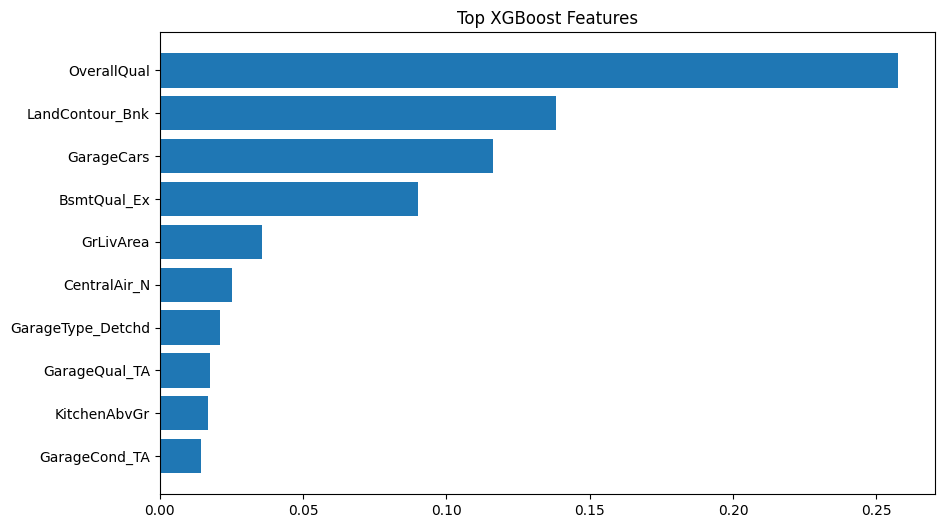

In [32]:
plt.figure(figsize=(10,6))

importance = xgb.feature_importances_

indices = np.argsort(importance)[-10:]

plt.barh(range(len(indices)), importance[indices])

plt.yticks(range(len(indices)), X.columns[indices])

plt.title("Top XGBoost Features")

plt.show()

### Problem 1.3: Stacked Ensemble

In [33]:
rf = RandomForestRegressor(n_estimators=200)

xgb = XGBRegressor()

nn = MLPRegressor(hidden_layer_sizes=(100,50), max_iter=500)

meta_model = Ridge()

In [15]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [10]:
!pip install optuna

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------  2.1/2.1 MB 12.6 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 8.7 MB/s  0:00:00

   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ------ --------------------------------- 1/6 [greenlet]
   ------ --------------------------------- 1/6 [greenlet]
   ------ --------------------------------- 1/6 [greenlet]
   ------ --------------------------------- 1/6 [greenlet]
   ------------- -------------------------- 2/6 [colorlog]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ---------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
!pip install ipywidgets

   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/914.9 kB ? eta -:--:--
   ---------------------- ----------------- 524.3/914.9 kB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 914.9/914.9 kB 2.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ------------------- -------------------- 1.0/2.2 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 6.3 MB/s  0:00:00

   ------------- -------------------------- 1/3 [jupyterlab_widgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import optuna

In [12]:
!pip install optuna xgboost lightgbm catboost psutil seaborn

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 9.2 MB/s eta 0:00:11
   - -------------------------------------- 3.9/101.7 MB 13.5 MB/s eta 0:00:08
   -- ------------------------------------- 6.8/101.7 MB 13.5 MB/s eta 0:00:08
   ---- ----------------------------------- 10.2/101.7 MB 14.4 MB/s eta 0:00:07
   ----- ---------------------------------- 13.9/101.7 MB 15.3 MB/s eta 0:00:06
   ------- -------------------------------- 18.1/101.7 MB 16.1 MB/s eta 0:00:06
   -------- ------------------------------- 22.0/101.7 MB 16.6 MB/s eta 0:00:05
   ---------- ----------------------------- 26.0/101.7 MB 17.0 MB/s eta 0:00:05
   ----------- ---------------------------- 29.9/101.7 MB 17.3 MB/s eta 0:00:05
   ------------- -------------------------- 34.1/101.7 MB 17.6 MB/s eta 0:00:04
   --------------- ------------------------ 38.3/101.7 MB 17.8 MB/s eta 0:00:04
   ---------------- ----------------------- 42.2/101.


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros((X_train.shape[0], 3))

for train_idx, val_idx in kf.split(X_train):

    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    rf.fit(X_tr, y_tr)
    xgb.fit(X_tr, y_tr)
    nn.fit(X_tr, y_tr)

    oof_preds[val_idx, 0] = rf.predict(X_val)
    oof_preds[val_idx, 1] = xgb.predict(X_val)
    oof_preds[val_idx, 2] = nn.predict(X_val)

ValueError: Input X contains NaN.
MLPRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values